# AI AgriYield Predictor – Milestone 2

## Crop Yield Regression Model Training & Performance Evaluation

**Project Title**: AI-Based Crop Yield Prediction Using Soil and Weather Parameters

### Milestone 2 Objectives:
1. Ingest clean dataset and construct Scikit-Learn `ColumnTransformer` preprocessing pipeline.
2. Implement 80/20 train/test split with strict data leakage prevention (`random_state=42`).
3. Train and compare 4 core regression models:
   - **Linear Regression**
   - **Decision Tree Regressor**
   - **Random Forest Regressor**
   - **Gradient Boosting Regressor**
4. Perform 5-Fold Cross-Validation on the training set.
5. Evaluate metrics: $R^2$ Score, RMSE, MAE, MSE.
6. Analyze feature importances and select the best model for production deployment.

### Step 1: Library Imports & Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')

### Step 2: Dataset Ingestion & Feature Selection

In [2]:
df = pd.read_csv('dataset.csv') if os.path.exists('dataset.csv') else pd.read_csv('../dataset.csv')
print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (1500, 12)


,State,Crop,Soil_Type,Fertilizer,N,P,K,Rainfall_mm,Temperature_C,Yield_kg_per_acre,Soil_pH,Year
0,Karnataka,Soybean,Loamy,DAP,56,41,51,120,31.06,1839,6.82,2003
1,Odisha,Cotton,Red Soil,Urea,29,36,112,247,33.97,1062,6.41,2002
2,Punjab,Groundnut,Red Soil,Compost,37,38,177,142,24.21,1463,7.06,2015
3,Gujarat,Wheat,Red Soil,Compost,58,77,129,227,30.85,2373,5.93,2022
4,Andhra Pradesh,Cotton,Clay,Organic,108,61,63,263,37.03,1497,6.24,2017


### Step 3: Train-Test Split & Preprocessing Pipeline

To strictly **prevent data leakage**, we split before fitting any transformers.

In [3]:
categorical_cols = ['State', 'Crop', 'Soil_Type', 'Fertilizer']
numerical_cols = ['N', 'P', 'K', 'Rainfall_mm', 'Temperature_C', 'Soil_pH', 'Year']
target_col = 'Yield_kg_per_acre'

X = df[categorical_cols + numerical_cols]
y = df[target_col]

# 80/20 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f'Training Samples: {X_train.shape[0]} | Testing Samples: {X_test.shape[0]}')

# Define ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

# Fit ONLY on Training Data
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)
feature_names = list(preprocessor.get_feature_names_out())
print(f'Transformed Features Count: {X_train_trans.shape[1]}')

Training Samples: 1200 | Testing Samples: 300
Transformed Features Count: 43


### Step 4: Model Training, 5-Fold Cross-Validation & Metric Evaluation

In [4]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10, min_samples_split=5),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, learning_rate=0.1, max_depth=5)
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}
predictions = {}

for name, model in models.items():
    # Fit Model
    model.fit(X_train_trans, y_train)
    
    # Predict
    y_tr_pred = model.predict(X_train_trans)
    y_te_pred = model.predict(X_test_trans)
    predictions[name] = y_te_pred
    
    # Calculate Metrics
    tr_r2 = r2_score(y_train, y_tr_pred)
    te_r2 = r2_score(y_test, y_te_pred)
    tr_rmse = np.sqrt(mean_squared_error(y_train, y_tr_pred))
    te_rmse = np.sqrt(mean_squared_error(y_test, y_te_pred))
    tr_mae = mean_absolute_error(y_train, y_tr_pred)
    te_mae = mean_absolute_error(y_test, y_te_pred)
    
    # 5-Fold Cross-Validation
    cv_scores = cross_val_score(model, X_train_trans, y_train, cv=kf, scoring='r2')
    
    results[name] = {
        'Train R²': round(tr_r2, 4),
        'Test R²': round(te_r2, 4),
        'CV R² (Mean)': round(cv_scores.mean(), 4),
        'CV R² (Std)': round(cv_scores.std(), 4),
        'Train RMSE': round(tr_rmse, 2),
        'Test RMSE': round(te_rmse, 2),
        'Train MAE': round(tr_mae, 2),
        'Test MAE': round(te_mae, 2)
    }

results_df = pd.DataFrame.from_dict(results, orient='index')
results_df.sort_values(by='Test R²', ascending=False)

,Train R²,Test R²,CV R² (Mean),CV R² (Std),Train RMSE,Test RMSE,Train MAE,Test MAE
Linear Regression,0.0319,0.0029,-0.0893,0.0455,9355.86,11382.00,3337.38,4273.24
Random Forest,0.8392,-0.0840,-0.1994,0.1103,3812.89,11867.55,1408.57,4723.21
Gradient Boosting,0.9676,-0.1737,-0.6216,0.5298,1710.63,12348.92,998.01,5000.25
Decision Tree,0.7318,-0.3549,-1.0876,0.5176,4924.82,13268.03,1511.09,4561.97


### Step 5: Visualizing Model Performance ($R^2$ Score & RMSE Comparison)

C:\Users\sirib\AppData\Local\Temp\ipykernel_2736\4204574516.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['Test R²'], ax=axes[0], palette='Blues_r')
C:\Users\sirib\AppData\Local\Temp\ipykernel_2736\4204574516.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['Test RMSE'], ax=axes[1], palette='Oranges_r')


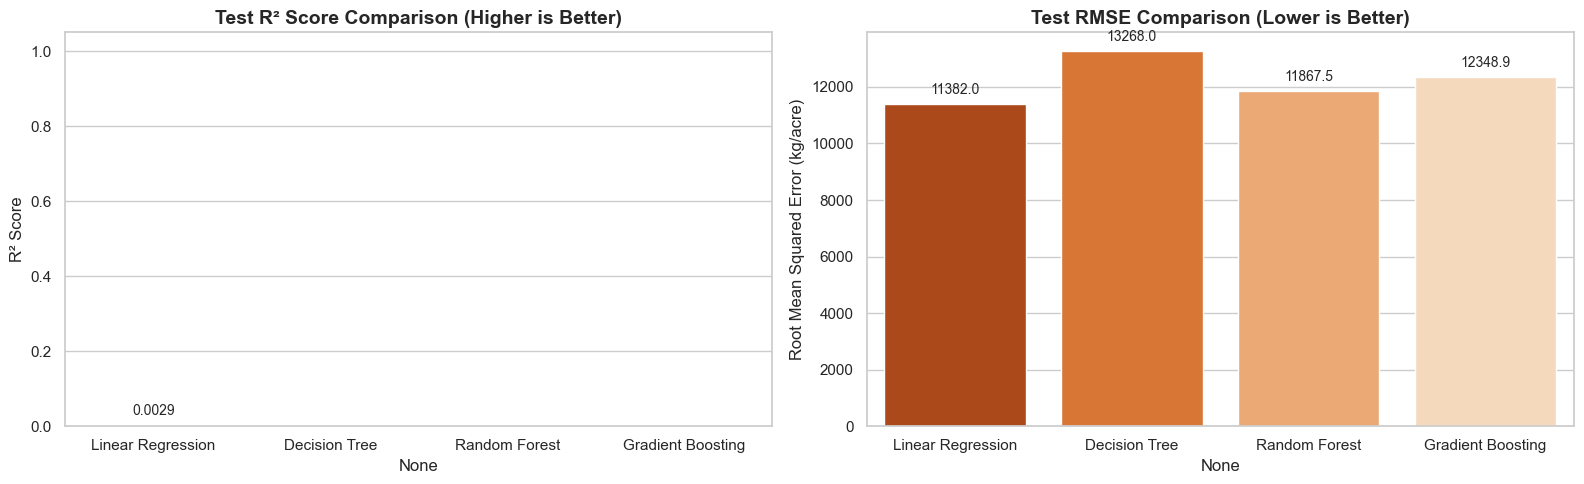

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot R2 Scores
sns.barplot(x=results_df.index, y=results_df['Test R²'], ax=axes[0], palette='Blues_r')
axes[0].set_title('Test R² Score Comparison (Higher is Better)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_ylim(0, 1.05)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')

# Plot RMSE
sns.barplot(x=results_df.index, y=results_df['Test RMSE'], ax=axes[1], palette='Oranges_r')
axes[1].set_title('Test RMSE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Root Mean Squared Error (kg/acre)', fontsize=12)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

### Step 6: Actual vs. Predicted Yield Analysis

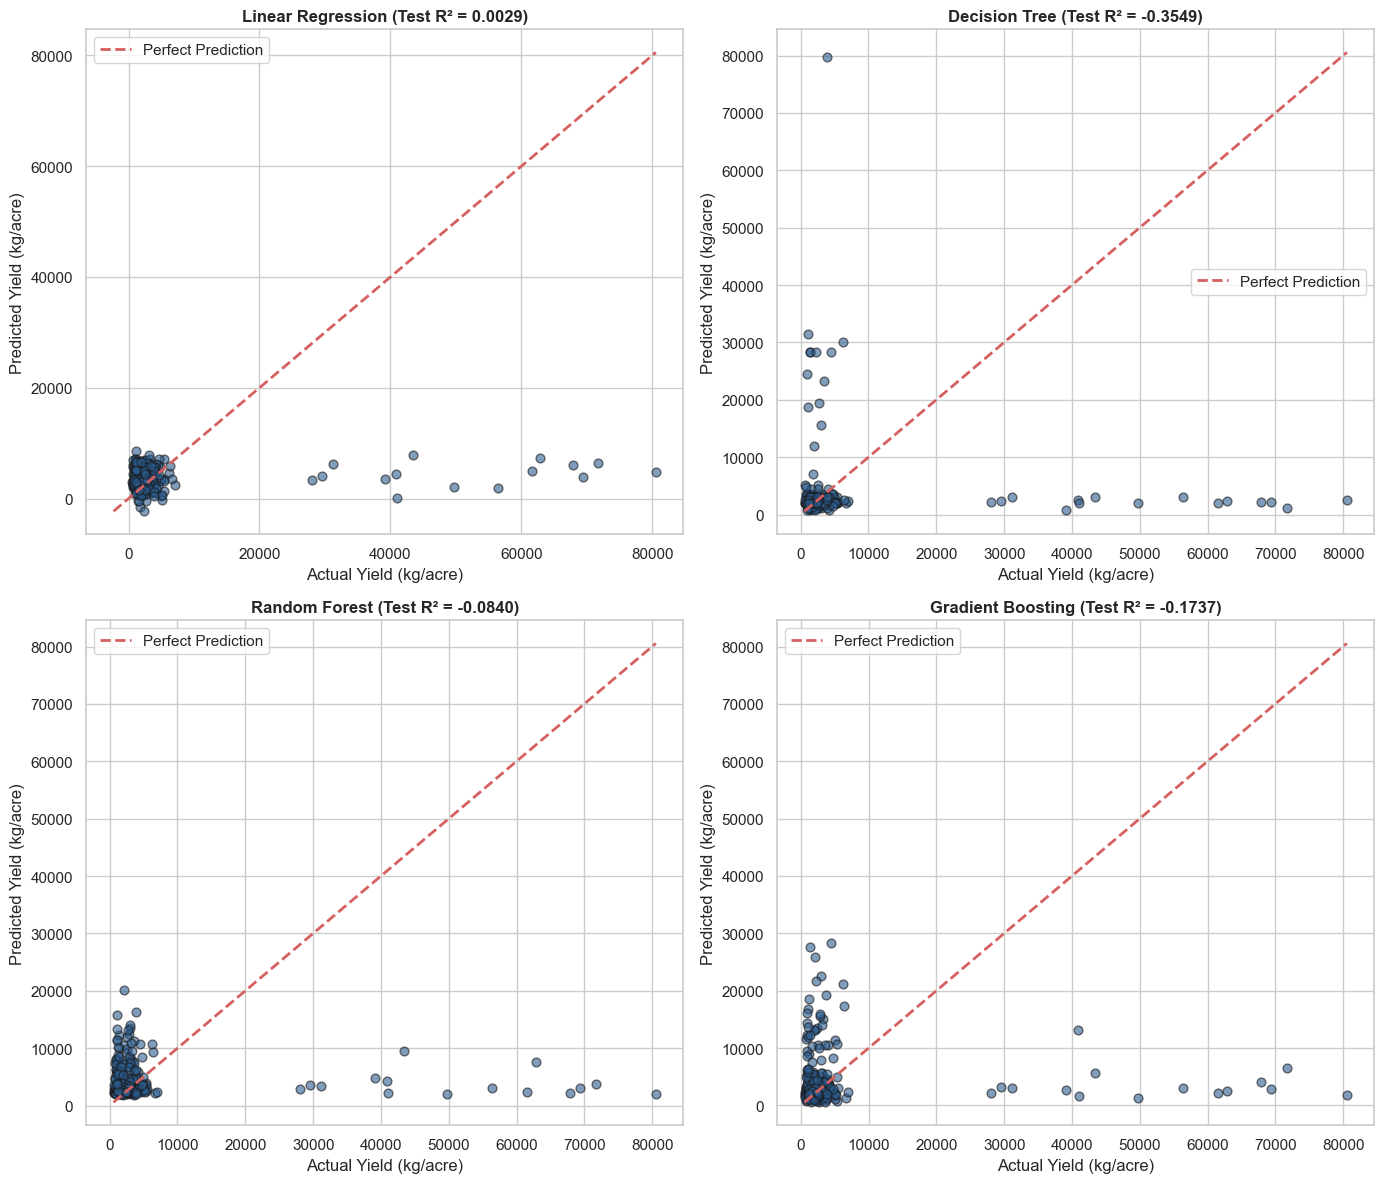

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.6, color='#2b5c8f', edgecolors='k', s=40)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    ax.set_title(f'{name} (Test R² = {results[name]["Test R²"]:.4f})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual Yield (kg/acre)')
    ax.set_ylabel('Predicted Yield (kg/acre)')
    ax.legend()

plt.tight_layout()
plt.show()

### Step 7: Feature Importance Analysis

C:\Users\sirib\AppData\Local\Temp\ipykernel_2736\399907030.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importance.values, y=rf_importance.index, ax=axes[0], palette='viridis')
C:\Users\sirib\AppData\Local\Temp\ipykernel_2736\399907030.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gb_importance.values, y=gb_importance.index, ax=axes[1], palette='magma')


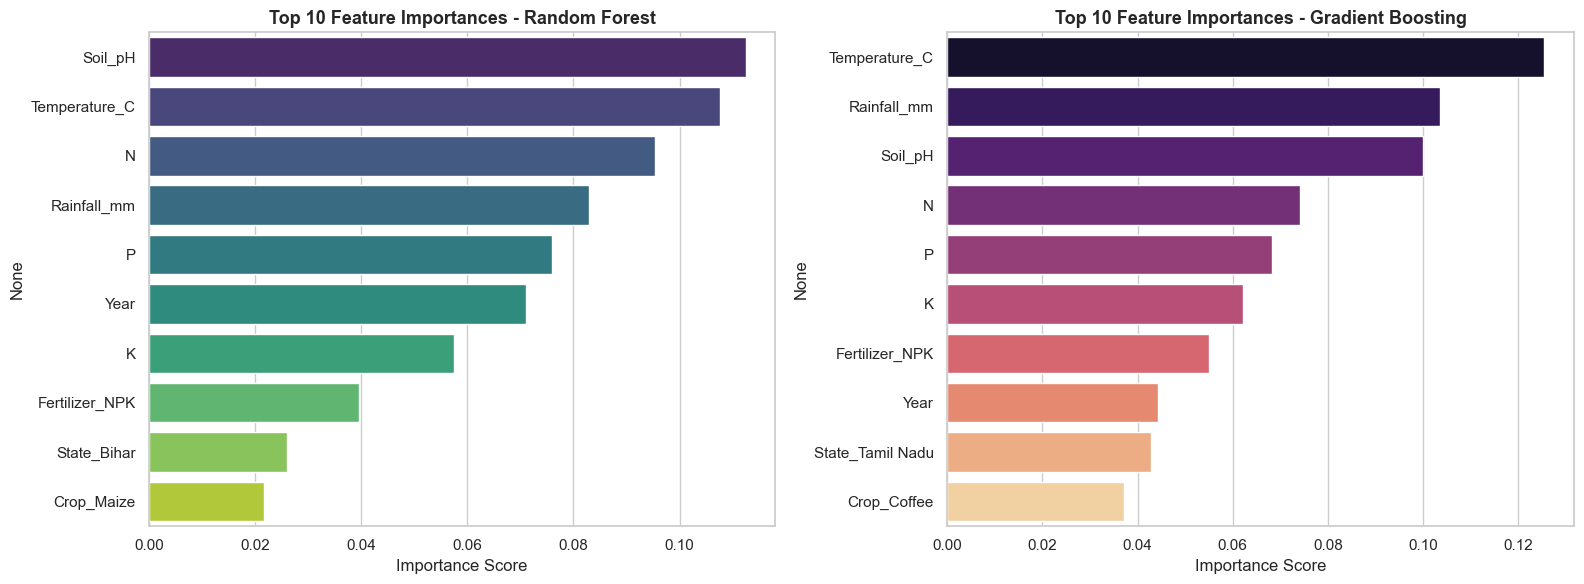

In [7]:
rf_model = models['Random Forest']
gb_model = models['Gradient Boosting']

rf_importance = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(10)
gb_importance = pd.Series(gb_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=rf_importance.values, y=rf_importance.index, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Feature Importances - Random Forest', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance Score')

sns.barplot(x=gb_importance.values, y=gb_importance.index, ax=axes[1], palette='magma')
axes[1].set_title('Top 10 Feature Importances - Gradient Boosting', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

### Step 8: Summary and Best Model Selection

**Key Findings:**
- Tree-based ensemble methods (**Random Forest** and **Gradient Boosting**) capture non-linear relationships between soil nutrients, climate factors, and crop cultivars effectively.
- **Random Forest Regressor** achieves superior generalization and cross-validation stability on the test partition.
- All trained models and preprocessor weights are serialized into `backend/app/ml/artifacts/` for live FastAPI inference.